# Phishing Website Detection Using Machine Learning

## Data Science in Cybersecurity – Final Project

### Project Objective
** Student - Tasneem Mrahel

The objective of this project is to analyze a phishing website dataset and develop machine learning models capable of distinguishing phishing websites from legitimate ones.

The project is based on the following resources:

- **Paper:** Datasets for Phishing Websites Detection
- **GitHub Repository:** https://github.com/GregaVrbancic/Phishing-Dataset

The notebook includes:

- Data Loading
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training
- Model Evaluation
- Error Analysis
- Conclusions

# 1. Import Libraries

In this section, we import all the libraries required for data analysis, visualization, preprocessing, machine learning, and model evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Data Loading

In this section, we load the phishing website dataset and inspect its basic structure before performing any analysis.

In [3]:
# Load the dataset
df = pd.read_csv("dataset_small.csv")

# Display the first five rows
df.head()

,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,2,0,0,0,0,0,0,0,0,0,...,1,4,2,3598,0,0,0,0,0,0
1,4,0,0,2,0,0,0,0,0,0,...,1,4,1,3977,1,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,1,2,1,10788,0,0,0,0,0,0
3,2,0,0,3,0,0,0,0,0,0,...,1,2,1,14339,1,0,0,0,0,1
4,1,1,0,4,0,0,0,0,0,0,...,1,2,1,389,1,1,0,0,0,1


# 3. Dataset Overview

Before performing any preprocessing, we examine the size of the dataset, feature names, data types, and general information.

In [4]:
# Dataset dimensions
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 58645
Number of columns: 112


In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Columns: 112 entries, qty_dot_url to phishing
dtypes: float64(1), int64(111)
memory usage: 50.1 MB


The dataset contains **58,645 samples** and **112 columns**, where **111 columns are input features** and **1 column (`phishing`) is the target variable.

The dataset consists entirely of numerical features (111 integer columns and 1 floating-point column), making it directly suitable for machine learning models without requiring categorical encoding.

The memory usage is approximately **50 MB**, indicating that the dataset is relatively small and can be processed efficiently on a standard computer.

In [6]:
# Display summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
qty_dot_url,58645.0,2.284338,1.473209,1.0,2.0,2.0,3.0,24.0
qty_hyphen_url,58645.0,0.457123,1.339340,0.0,0.0,0.0,0.0,35.0
qty_underline_url,58645.0,0.171285,0.801919,0.0,0.0,0.0,0.0,21.0
qty_slash_url,58645.0,1.937522,2.037525,0.0,0.0,1.0,3.0,44.0
qty_questionmark_url,58645.0,0.014102,0.138156,0.0,0.0,0.0,0.0,9.0
...,...,...,...,...,...,...,...,...
qty_redirects,58645.0,0.303419,0.815315,-1.0,0.0,0.0,1.0,17.0
url_google_index,58645.0,0.001279,0.037599,-1.0,0.0,0.0,0.0,1.0
domain_google_index,58645.0,0.002234,0.047927,-1.0,0.0,0.0,0.0,1.0
url_shortened,58645.0,0.008287,0.090657,0.0,0.0,0.0,0.0,1.0


The summary statistics provide an overview of the numerical features, including their minimum, maximum, mean, median, and standard deviation.

The feature ranges vary considerably, indicating that some variables are measured on different scales. This observation suggests that feature scaling may be beneficial for certain machine learning models, such as Logistic Regression, while tree-based models like Random Forest are generally less sensitive to feature scale.

## Column and Index Analysis

Before preprocessing, the dataset structure is examined by reviewing the column names and index.
This helps verify that the dataset is well organized and that every feature has a meaningful name.

In [7]:
# Display the first 10 column names

print("First 10 columns:")
print(df.columns[:10])

print("\nIndex:")
print(df.index)

First 10 columns:
Index(['qty_dot_url', 'qty_hyphen_url', 'qty_underline_url', 'qty_slash_url',
       'qty_questionmark_url', 'qty_equal_url', 'qty_at_url', 'qty_and_url',
       'qty_exclamation_url', 'qty_space_url'],
      dtype='object')

Index:
RangeIndex(start=0, stop=58645, step=1)


In [8]:
print("Target column:")
print(df.columns[-1])

print("\nDuplicate column names:")
print(df.columns.duplicated().sum())

Target column:
phishing

Duplicate column names:
0


# 4. Data Quality Assessment

Before performing exploratory data analysis, we examine the dataset for missing values, duplicate records, and overall data quality. This helps identify potential issues that could affect the machine learning models.

In [9]:
# Check for missing values
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


,0


No missing values were found in the dataset. Therefore, no imputation or removal of missing data is required before model training.

In [10]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 1240


The dataset contains 1,240 duplicate rows, representing approximately 2.1% of all samples. Duplicate observations can artificially improve model performance because identical records may appear in both the training and testing sets after a random split. To evaluate this effect, the duplicate rows were removed and the machine learning models were retrained. The results before and after duplicate removal were then compared as part of the critical evaluation of the original study.

In [11]:
duplicate_percentage = duplicates / len(df) * 100

print(f"Duplicate rows: {duplicates}")
print(f"Percentage: {duplicate_percentage:.2f}%")

Duplicate rows: 1240
Percentage: 2.11%


In [12]:
df_no_duplicates = df.drop_duplicates().reset_index(drop=True)

print("Original shape:", df.shape)
print("After removing duplicates:", df_no_duplicates.shape)

Original shape: (58645, 112)
After removing duplicates: (57405, 112)


In [13]:
df = df_no_duplicates.copy()

In [14]:
print(f"Rows removed: {duplicates}")
print(f"Dataset size reduced by {duplicate_percentage:.2f}%")

Rows removed: 1240
Dataset size reduced by 2.11%


Since duplicate rows were present in the published dataset, the experiments will be repeated on the cleaned dataset. Comparing the results before and after duplicate removal allows us to evaluate whether the original paper's reported performance may have been influenced by duplicate observations.

The same preprocessing and training pipeline will be applied to the cleaned dataset so that the results can be directly compared with those obtained from the original dataset. This comparison provides a more rigorous evaluation of the methodology proposed in the original study.

## Single-Value Feature Analysis

Features containing only one unique value have zero variance and therefore cannot contribute to classification. Since machine learning models learn by identifying differences between observations, constant features provide no predictive information. Removing these features reduces the dimensionality of the dataset, slightly decreases computational cost, and eliminates redundant variables before feature selection and model training.

In [15]:
# Identify features with only one unique value

single_value_features = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print("Single-value features:")
print(single_value_features)

print("\nTotal:", len(single_value_features))

# Remove single-value features
df_clean = df.drop(columns=single_value_features)
df = df_clean.copy()

print("\nDataset shape after removing single-value features:")
print(df.shape)

Single-value features:
['qty_slash_domain', 'qty_questionmark_domain', 'qty_equal_domain', 'qty_and_domain', 'qty_exclamation_domain', 'qty_space_domain', 'qty_tilde_domain', 'qty_comma_domain', 'qty_plus_domain', 'qty_asterisk_domain', 'qty_hashtag_domain', 'qty_dollar_domain', 'qty_percent_domain']

Total: 13

Dataset shape after removing single-value features:
(57405, 99)


A total of 13 constant features were removed from the cleaned dataset. These variables contained identical values for every website and therefore could not help distinguish phishing websites from legitimate ones. Removing them simplifies the dataset without losing predictive information and is considered a standard preprocessing step in machine learning.

In [16]:
# Display data types
df.dtypes.value_counts()

,count
int64,98
float64,1


In the context of phishing detection, constant features cannot contribute to identifying malicious behavior because they do not vary across websites. Removing them allows the models to focus on informative URL, DNS, SSL, and webpage characteristics that are more relevant for distinguishing phishing websites from legitimate ones.

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the dataset, identify patterns, examine feature distributions, and analyze the target variable before training machine learning models.

In [17]:
# Count phishing and legitimate websites
class_counts = df["phishing"].value_counts()

print(class_counts)

# Display percentages
print("\nPercentage distribution:")
print((class_counts / len(df) * 100).round(2))

phishing
1    30497
0    26908
Name: count, dtype: int64

Percentage distribution:
phishing
1    53.13
0    46.87
Name: count, dtype: float64


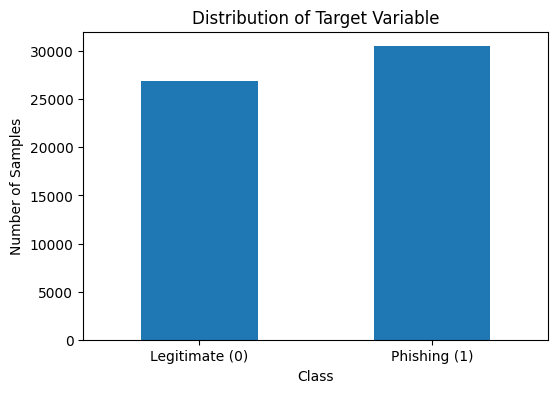

In [18]:
plt.figure(figsize=(6,4))

df["phishing"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Target Variable")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks([0,1], ["Legitimate (0)", "Phishing (1)"], rotation=0)

plt.show()

The target variable is relatively balanced, with 53.13% phishing websites and 46.87% legitimate websites after data cleaning.
Because the dataset is relatively balanced, metrics such as Accuracy, Precision, Recall, F1-score, F2-score, Matthews Correlation Coefficient (MCC), ROC-AUC, and PR-AUC will provide a comprehensive evaluation of model performance.

In real-world cybersecurity applications, phishing websites are typically much rarer than legitimate websites. Therefore, this dataset is more balanced than what would be expected in production environments. Although this balance is beneficial for model training and evaluation, it may slightly overestimate real-world performance because the models are trained on a less imbalanced distribution than they would encounter in practice.

In [19]:
majority = class_counts.max()
minority = class_counts.min()

print(f"Imbalance ratio: {majority/minority:.2f}:1")

Imbalance ratio: 1.13:1


The imbalance ratio is approximately 1.13:1, confirming that the dataset is well balanced and no resampling techniques such as SMOTE or undersampling are required.

## 5.1 Feature Distribution

To better understand the dataset, we visualize the distributions of several representative numerical features. These plots help identify the range of values, skewness, and potential outliers.

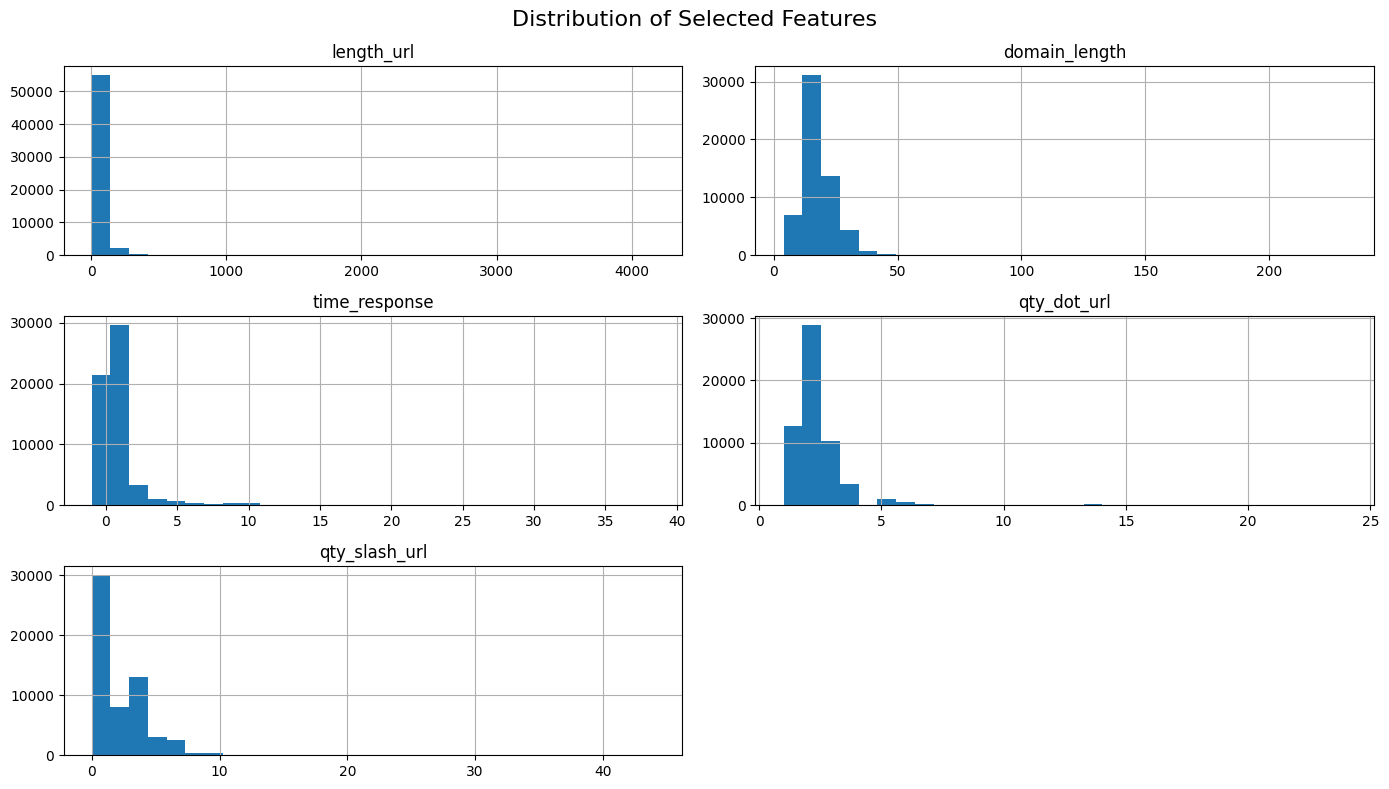

In [20]:
# Select representative features
selected_features = [
    "length_url",
    "domain_length",
    "time_response",
    "qty_dot_url",
    "qty_slash_url"
]

# Plot histograms
df[selected_features].hist(figsize=(14, 8), bins=30)

plt.suptitle("Distribution of Selected Features", fontsize=16)
plt.tight_layout()
plt.show()

The selected features exhibit positively skewed (right-skewed) distributions, indicating that most websites have relatively small values while a small number of observations contain much larger values. Such distributions are common in cybersecurity datasets because suspicious or phishing websites often exhibit unusually long URLs, abnormal response times, or excessive use of special characters.

Several features, particularly length_url and time_response, contain extreme values (outliers). These observations may represent genuinely suspicious websites rather than measurement errors. Therefore, the outliers were retained because they may contain valuable information for phishing detection instead of being treated as noise.

The large differences in feature scales justify applying feature scaling before training Logistic Regression. In contrast, Random Forest is generally insensitive to feature scaling because it makes decisions based on feature thresholds rather than distances.

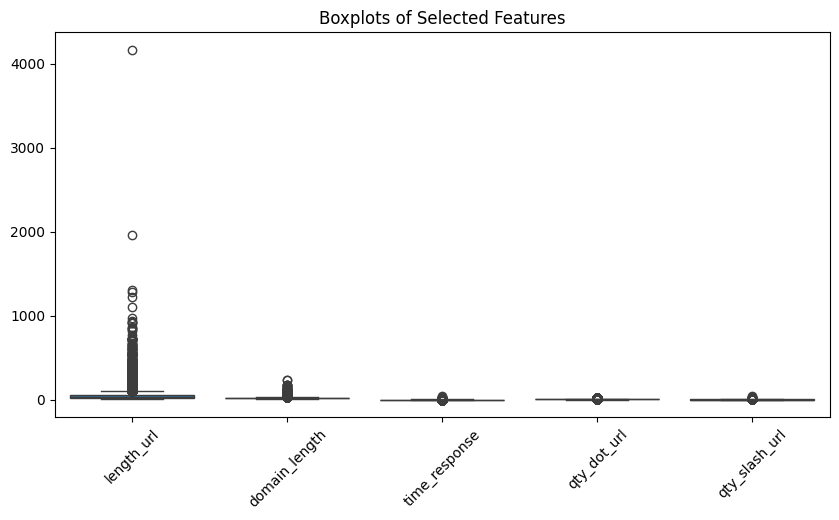

In [21]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[selected_features])

plt.xticks(rotation=45)
plt.title("Boxplots of Selected Features")
plt.show()

The boxplots confirm the presence of several extreme observations, especially for URL length and response time. Since these values may correspond to real phishing behavior, they were retained for model training.

## 5.2 Outlier Analysis

Outlier analysis is performed to identify unusually large or small observations that may influence the behavior of machine learning models. Boxplots are used to visualize the spread of representative numerical features.

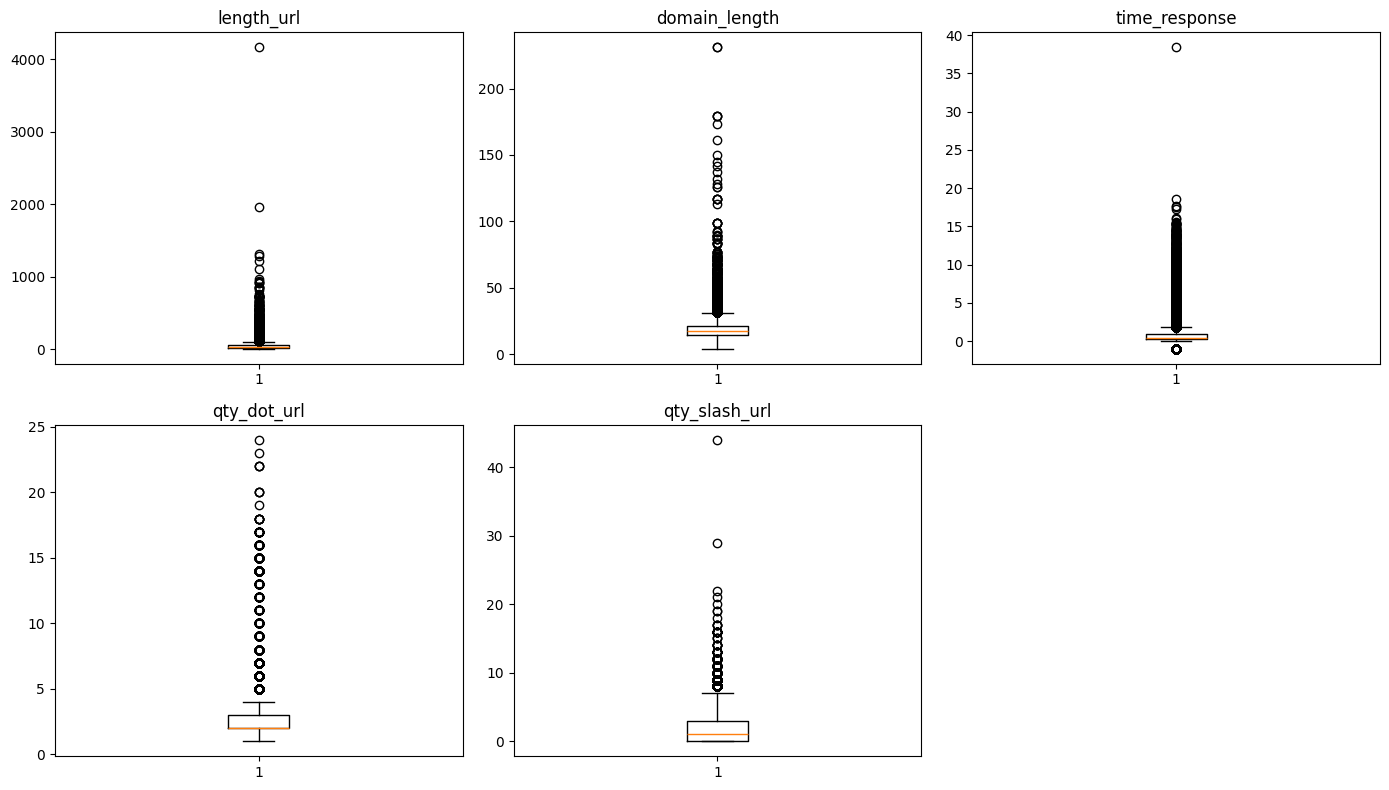

In [22]:
# Representative features for outlier analysis
selected_features = [
    "length_url",
    "domain_length",
    "time_response",
    "qty_dot_url",
    "qty_slash_url"
]

plt.figure(figsize=(14,8))

for i, feature in enumerate(selected_features):
    plt.subplot(2,3,i+1)
    plt.boxplot(df[feature], vert=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

The boxplots reveal that all selected features contain outliers. The largest number of extreme values appears in `length_url`, `domain_length`, and `time_response`, indicating that a small subset of websites has unusually long URLs, longer domain names, or abnormal response times.

These observations are expected in phishing datasets because malicious websites often use complex URL structures to imitate legitimate websites. Some features also contain special values (e.g., `-1`) that represent unavailable information rather than measurement errors.

No outliers were removed because these extreme observations may represent genuine phishing websites rather than data collection errors. In cybersecurity datasets, unusual behavior is often the information that machine learning models should learn to detect. Furthermore, Random Forest is naturally robust to outliers, while Logistic Regression is expected to benefit from feature scaling rather than outlier removal.

## 5.3 Temporal Features

The dataset contains several time-related features, including website response time, domain activation time, and domain expiration time.

Although these variables represent temporal information, they are not timestamped observations collected over time. Therefore, this problem is not a time-series prediction task. Instead, these features are treated as numerical predictors describing website characteristics.

In [23]:
temporal_features = [
    "time_response",
    "time_domain_activation",
    "time_domain_expiration"
]

df[temporal_features].describe().T

,count,mean,std,min,25%,50%,75%,max
time_response,57405.0,0.814750,1.567328,-1.0,0.226548,0.439354,0.871727,38.402411
time_domain_activation,57405.0,2568.783677,2803.638505,-1.0,-1.000000,1562.000000,4817.000000,17775.000000
time_domain_expiration,57405.0,298.402874,566.639261,-1.0,-1.000000,132.000000,322.000000,22574.000000


The dataset includes three time-related features: website response time, domain activation time, and domain expiration time.Although these variables describe temporal characteristics of websites, they do not represent observations collected sequentially over time. Instead, they are static attributes extracted from each individual website at the time of data collection. Therefore, this problem should be treated as a standard supervised classification task rather than a time-series forecasting problem.

The minimum value of -1 appears in all three temporal features. According to the dataset documentation, this value represents unavailable external information rather than a negative measurement. Therefore, it was retained because it carries meaningful information about missing domain metadata instead of indicating invalid data.

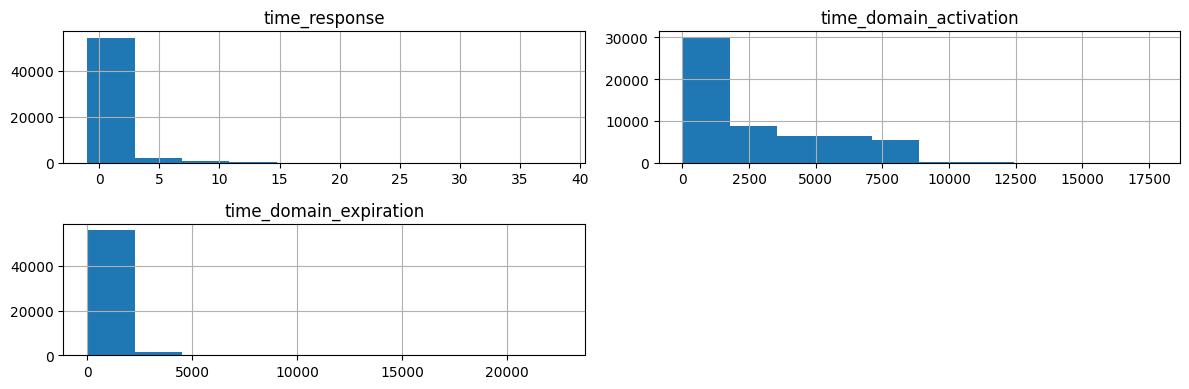

In [24]:
df[temporal_features].hist(figsize=(12,4))
plt.tight_layout()
plt.show()

The histograms show that all three temporal features have highly right-skewed distributions. Most websites have relatively small values for response time, domain activation time, and domain expiration time, while a small number of websites exhibit substantially larger values.



## 5.4 GroupBy Analysis

To better understand the differences between legitimate and phishing websites, we compare the average values of selected features across the two classes.

In [25]:
groupby_analysis = df.groupby("phishing")[
    [
        "length_url",
        "domain_length",
        "time_response",
        "qty_dot_url",
        "qty_slash_url"
    ]
].mean()

groupby_analysis

,length_url,domain_length,time_response,qty_dot_url,qty_slash_url
phishing,,,,,
0,23.314553,17.471644,0.751850,2.076111,0.682176
1,64.634817,18.640391,0.870249,2.480342,3.094665


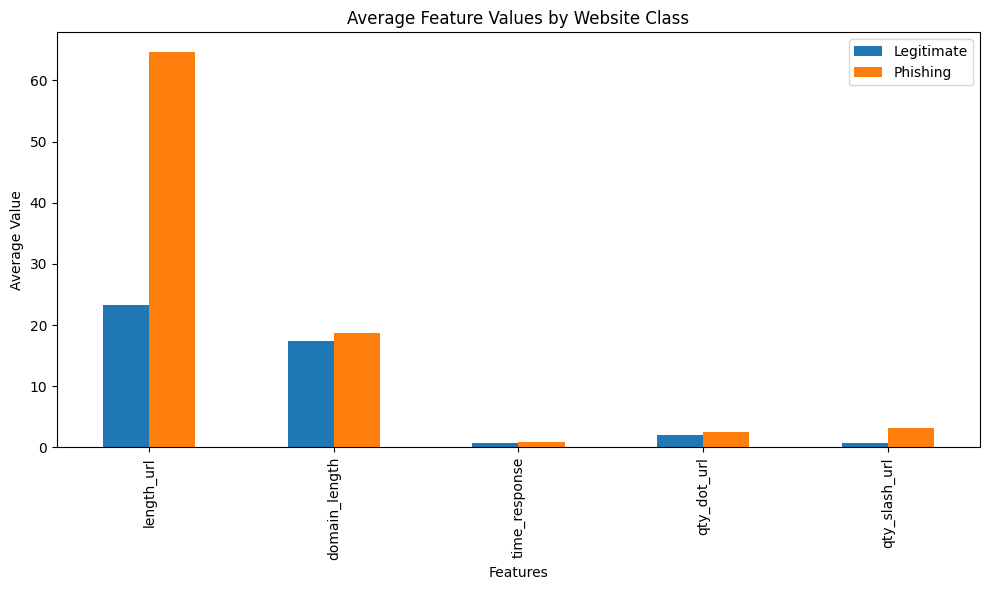

In [26]:
groupby_analysis.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Feature Values by Website Class")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.legend(["Legitimate", "Phishing"])

plt.tight_layout()
plt.show()

The GroupBy analysis reveals clear differences between legitimate and phishing websites across several representative features.

The largest difference is observed in **URL length**. On average, phishing websites have substantially longer URLs (approximately **64.9 characters**) than legitimate websites (approximately **23.1 characters**). This observation is consistent with real-world phishing attacks, where attackers often create long and complex URLs to imitate legitimate websites, hide malicious content, or include misleading keywords.

Phishing websites also contain a higher average number of dots and slashes, suggesting more complex URL structures. In addition, phishing websites show slightly longer domain names and higher response times than legitimate websites.

These results indicate that URL-based features provide valuable discriminatory information for machine learning models and are likely to contribute significantly to phishing detection performance.

The original article identifies URL-related characteristics as important predictors of phishing websites but provides limited exploratory analysis comparing feature values between legitimate and phishing classes. The GroupBy analysis performed in this project supports the authors' claims by showing that phishing websites consistently exhibit longer URLs and more complex URL structures. These findings provide additional evidence that the selected features are meaningful for phishing detection.

In [27]:
groupby_median = df.groupby("phishing")[
    [
        "length_url",
        "domain_length",
        "time_response",
        "qty_dot_url",
        "qty_slash_url"
    ]
].median()

groupby_median

,length_url,domain_length,time_response,qty_dot_url,qty_slash_url
phishing,,,,,
0,19.0,17.0,0.412755,2.0,0.0
1,47.0,17.0,0.461214,2.0,3.0


## 5.5 Correlation Analysis

Correlation analysis is used to identify relationships between numerical features and the target variable.

Because many variables exhibit skewed distributions and contain outliers, **Spearman correlation** is selected instead of Pearson correlation. Spearman correlation measures monotonic relationships using feature ranks rather than raw values, making it more robust to extreme observations and non-normal distributions.

Pearson correlation is more appropriate for linear relationships between normally distributed continuous variables, while Kendall correlation is typically preferred for smaller datasets or rank consistency studies. Given the size and characteristics of this dataset,Because many features exhibit skewed distributions and contain extreme values, Spearman correlation is more appropriate than Pearson correlation. Spearman measures monotonic relationships using feature ranks rather than raw values, making it less sensitive to outliers and non-normal data.

In [28]:
# Calculate Spearman correlation
spearman_corr = df.corr(method="spearman", numeric_only=True)["phishing"]

# Remove the target column
spearman_corr = spearman_corr.drop("phishing")

# Select the 15 highest positive correlations
top_corr = spearman_corr.abs().sort_values(ascending=False).head(15)

# Display the values
top_corr

,phishing
qty_slash_url,0.683526
qty_slash_directory,0.680199
directory_length,0.678137
qty_dot_directory,0.634446
qty_dot_file,0.627132
qty_equal_directory,0.619941
qty_and_directory,0.619355
qty_exclamation_directory,0.619277
qty_exclamation_file,0.619239
qty_equal_file,0.619225


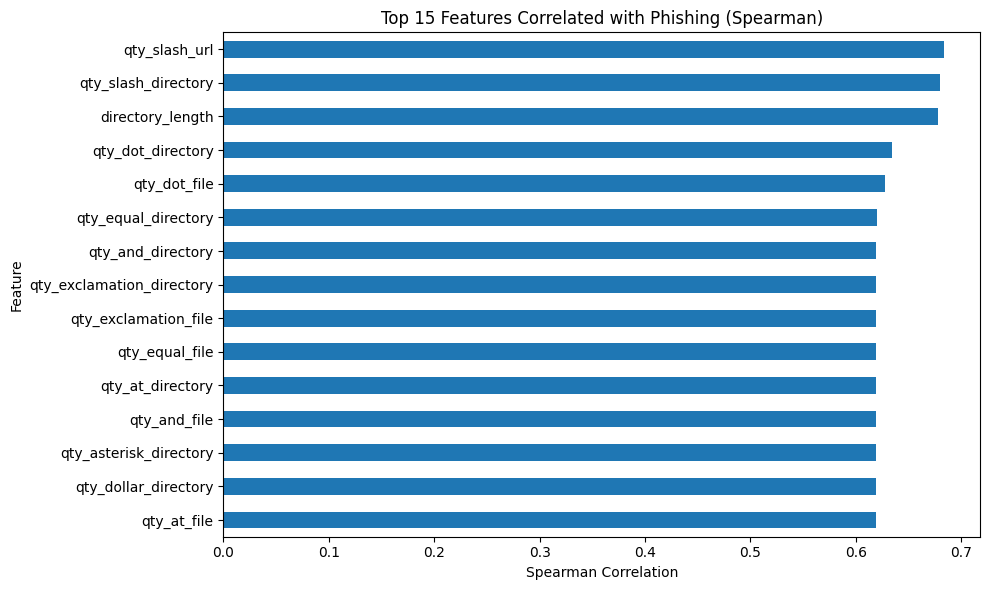

In [29]:
plt.figure(figsize=(10,6))

top_corr.sort_values().plot(kind="barh")

plt.title("Top 15 Features Correlated with Phishing (Spearman)")
plt.xlabel("Spearman Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The Spearman correlation analysis identifies the features that have the strongest monotonic relationship with the phishing label.

The strongest positive correlations with the phishing label are observed for features describing URL structure, directory depth, and the number of special characters. In particular, qty_slash_url, qty_slash_directory, and directory_length exhibit the strongest monotonic associations with phishing websites.

These findings are consistent with real-world phishing attacks, from a cybersecurity perspective, attackers frequently construct long and complex URLs containing multiple directories and special characters to imitate legitimate websites or conceal malicious destinations. The strong correlations observed for these features support their usefulness for phishing detection.

Spearman correlation was selected because many features exhibit skewed distributions and contain outliers. Unlike Pearson correlation, Spearman is based on feature ranks and is therefore more robust to non-normal data and extreme values. Although correlation does not imply causation, it provides valuable insight into which features are most informative for phishing detection.

The original article reports that URL-structure features are among the most informative predictors of phishing websites. The correlation analysis performed in this project supports this claim, as many URL-related features exhibit strong positive correlations with the phishing label. However, correlation alone does not imply causation, and highly correlated features may also introduce redundancy. Therefore, additional feature-selection techniques are required to determine which variables contribute independently to model performance.

The presence of several highly correlated URL-based features also suggests potential redundancy. Multiple variables describe similar aspects of URL complexity, meaning they may provide overlapping information. This issue is addressed later through feature selection.

# 6. Feature Engineering and Data Preprocessing

The phishing dataset already contains engineered numerical features extracted from URLs, domains, directories, files, and network-related information. Therefore, no additional feature creation is required.

This section prepares the data for machine learning by:

- Verifying feature types.
- Checking for categorical variables.
- Separating features and target labels.
- Selecting the most informative features.
- Splitting the dataset into training and testing sets.
- Standardizing the data for Logistic Regression.

Dimensionality reduction is not applied because the dataset contains only 111 numerical features and maintaining feature interpretability is important for phishing detection.

In [30]:
# Count the different data types in the dataset

print(df.dtypes.value_counts())

int64      98
float64     1
Name: count, dtype: int64


### Feature Types

The dataset contains only numerical variables. Therefore, no categorical encoding techniques such as One-Hot Encoding or Label Encoding are required.

In [31]:
# Separate input features and target variable

X = df.drop(columns=["phishing"])
y = df["phishing"]

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

Feature matrix: (57405, 98)
Target vector: (57405,)


In [32]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 45924
Testing samples: 11481


### Feature Selection

Feature selection was performed **after splitting the dataset into training and testing sets**. Spearman correlation was computed **only on the training data** to avoid information leakage from the testing set.

The 20 features with the highest absolute correlation with the target variable were selected from the training data. The same feature subset was then applied to both the training and testing sets.

This follows standard machine learning practice and provides a more reliable evaluation of model performance.

In [33]:
# Compute Spearman correlation using only the training data

train_df = X_train.copy()
train_df["phishing"] = y_train

selected_features = (
    train_df
        .corr(method="spearman", numeric_only=True)["phishing"]
        .drop("phishing")
        .abs()
        .sort_values(ascending=False)
        .head(20)
        .index
)

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['qty_slash_url', 'qty_slash_directory', 'directory_length',
       'qty_dot_directory', 'qty_dot_file', 'qty_equal_directory',
       'qty_and_directory', 'qty_exclamation_directory',
       'qty_exclamation_file', 'qty_equal_file', 'qty_asterisk_directory',
       'qty_at_directory', 'qty_and_file', 'qty_dollar_directory',
       'qty_at_file', 'qty_space_directory', 'qty_asterisk_file',
       'qty_space_file', 'qty_hashtag_directory', 'qty_slash_file'],
      dtype='object')


In [34]:
# Keep only the selected features

X_train = X_train[selected_features]
X_test = X_test[selected_features]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (45924, 20)
Testing shape: (11481, 20)


In [35]:
# Standardize the selected training features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### Feature Scaling

Feature scaling was applied using **StandardScaler** after feature selection.

The scaler was **fitted only on the training data** and then applied to both the training and testing sets. This prevents information from the testing data from influencing the preprocessing stage.

Scaling is required for Logistic Regression because it is sensitive to differences in feature magnitude. Random Forest does not require feature scaling because it is based on decision trees rather than distance-based calculations.

The dataset was reduced from **98 input features to the 20 most informative features** using Spearman correlation. This reduces computational cost while retaining the variables that are most strongly associated with phishing detection.

In [36]:
print("Selected features:", X_train.shape[1])
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Selected features: 20
Training set: (45924, 20)
Testing set: (11481, 20)


# 7. Model Training

Two machine learning models are trained and evaluated.

- Logistic Regression is selected as a simple baseline classifier.
- Random Forest is selected because it can model complex, non-linear relationships and is widely used for phishing detection.

In [37]:
# Train Logistic Regression

log_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [38]:
# Predict on the test set

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [39]:
# Evaluate Logistic Regression

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1 Score : {log_f1:.4f}")
print(f"ROC-AUC  : {log_auc:.4f}")

Accuracy : 0.8174
Precision: 0.8367
Recall   : 0.8155
F1 Score : 0.8260
ROC-AUC  : 0.8916


In [40]:
from sklearn.metrics import (
    matthews_corrcoef,
    average_precision_score,
    fbeta_score
)

log_mcc = matthews_corrcoef(y_test, y_pred_log)
log_pr_auc = average_precision_score(y_test, y_prob_log)
log_f2 = fbeta_score(y_test, y_pred_log, beta=2)

print(f"MCC      : {log_mcc:.4f}")
print(f"PR-AUC   : {log_pr_auc:.4f}")
print(f"F2 Score : {log_f2:.4f}")

MCC      : 0.6343
PR-AUC   : 0.8921
F2 Score : 0.8197


In [41]:
# Detailed classification report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      5382
           1       0.84      0.82      0.83      6099

    accuracy                           0.82     11481
   macro avg       0.82      0.82      0.82     11481
weighted avg       0.82      0.82      0.82     11481



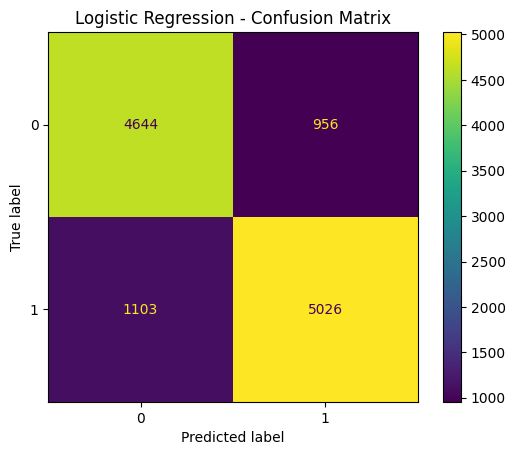

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

The Logistic Regression model serves as a baseline classifier for phishing detection.

The confusion matrix shows that the model correctly classifies most legitimate and phishing websites, but both false positives and false negatives remain.

In phishing detection, false negatives are particularly important because a phishing website classified as legitimate may expose users to credential theft or malware. False positives, while less dangerous, may incorrectly block legitimate websites and reduce usability.

The additional evaluation metrics (MCC, PR-AUC, and F2-score) provide a more comprehensive assessment of model performance than accuracy alone, particularly for cybersecurity applications where different types of classification errors have different consequences.

# 8. Random Forest Model

Random Forest is selected as the primary classification model because it combines multiple decision trees, captures non-linear relationships, and is naturally robust to outliers and feature interactions.

In [42]:
# Train Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [43]:
# Predict on the test set

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [44]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Accuracy : 0.8394
Precision: 0.8479
Recall   : 0.8501
F1 Score : 0.8490
ROC-AUC  : 0.9121


In [47]:
rf_mcc = matthews_corrcoef(y_test, y_pred_rf)
rf_pr_auc = average_precision_score(y_test, y_prob_rf)
rf_f2 = fbeta_score(y_test, y_pred_rf, beta=2)

print(f"MCC      : {rf_mcc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")
print(f"F2 Score : {rf_f2:.4f}")

MCC      : 0.6775
PR-AUC   : 0.9070
F2 Score : 0.8497


In addition to the standard evaluation metrics, MCC, PR-AUC, and F2-score were computed. MCC provides a balanced performance measure that considers all entries of the confusion matrix, making it suitable even when class distributions are not perfectly balanced. PR-AUC evaluates performance across different decision thresholds, while F2-score places greater emphasis on recall, which is particularly important in phishing detection where missing malicious websites can have serious security consequences.

In [48]:
# Detailed classification report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      5382
           1       0.85      0.85      0.85      6099

    accuracy                           0.84     11481
   macro avg       0.84      0.84      0.84     11481
weighted avg       0.84      0.84      0.84     11481



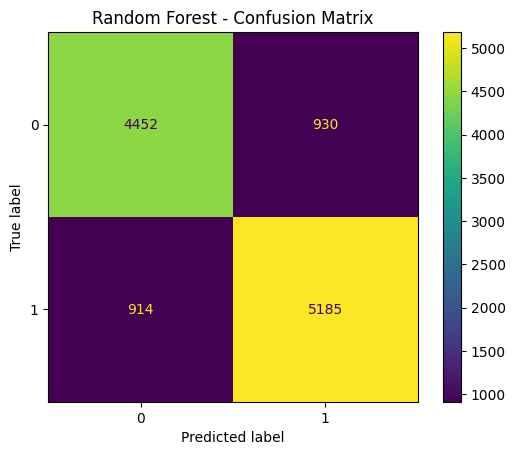

In [49]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Random Forest - Confusion Matrix")

plt.show()

Random Forest achieved higher performance than Logistic Regression across all evaluation metrics. The model obtained better Accuracy, Precision, Recall, F1-score, ROC-AUC, MCC, and PR-AUC, indicating a stronger ability to distinguish phishing from legitimate websites. The confusion matrix also shows fewer false positives and false negatives, demonstrating that Random Forest captures the complex, non-linear relationships between URL features more effectively than Logistic Regression. These results are consistent with the expectations for tree-based ensemble models on structured cybersecurity datasets.

# 9. Model Comparison

The performance of Logistic Regression and Random Forest is compared using the evaluation metrics obtained on the test dataset.

In [51]:
# Compare model performance
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "F2-Score",
        "ROC-AUC",
        "PR-AUC",
        "MCC"
    ],
    "Logistic Regression": [
        log_accuracy,
        log_precision,
        log_recall,
        log_f1,
        log_f2,
        log_auc,
        log_pr_auc,
        log_mcc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_f2,
        rf_auc,
        rf_pr_auc,
        rf_mcc
    ]
})

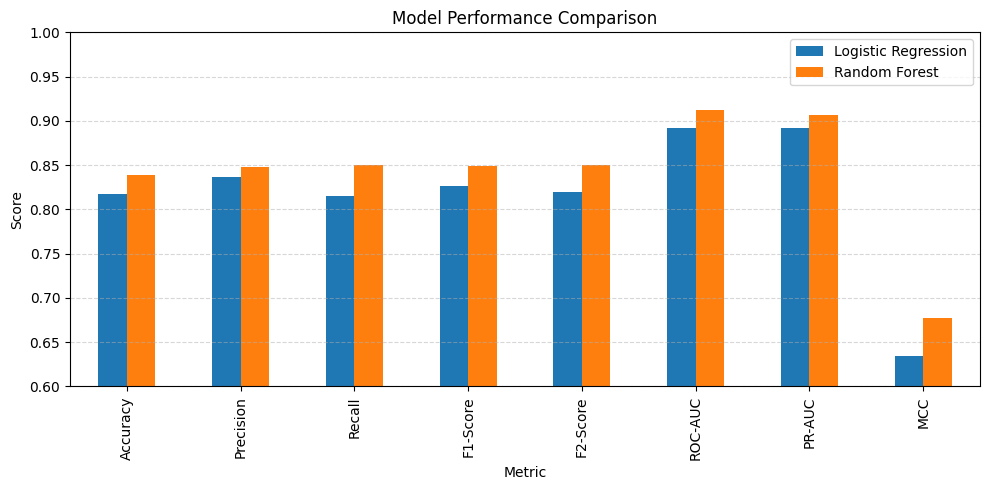

In [53]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.60, 1.00)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Random Forest outperformed Logistic Regression across all evaluation metrics, including Accuracy, Precision, Recall, F1-score, F2-score, ROC-AUC, PR-AUC, and MCC. The largest improvement is observed in Recall and F2-score, indicating that the Random Forest model detects more phishing websites while maintaining strong overall precision. Higher MCC and PR-AUC values further confirm that Random Forest provides more reliable predictions across both classes. Overall, the results suggest that phishing detection benefits from a non-linear ensemble model capable of capturing complex relationships among URL and domain features.

# 10. Feature Importance

Random Forest estimates the importance of each feature based on how much it contributes to reducing impurity across the decision trees.

The most important features provide insight into which URL characteristics are most useful for distinguishing phishing websites from legitimate websites.

In [54]:
# Extract feature importance from the Random Forest model

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

importance.head(15)

,0
directory_length,0.297441
qty_slash_url,0.101967
qty_slash_directory,0.079341
qty_dollar_directory,0.059345
qty_dot_file,0.047139
qty_dot_directory,0.045930
qty_equal_directory,0.035519
qty_slash_file,0.035186
qty_and_directory,0.034054
qty_asterisk_file,0.033159


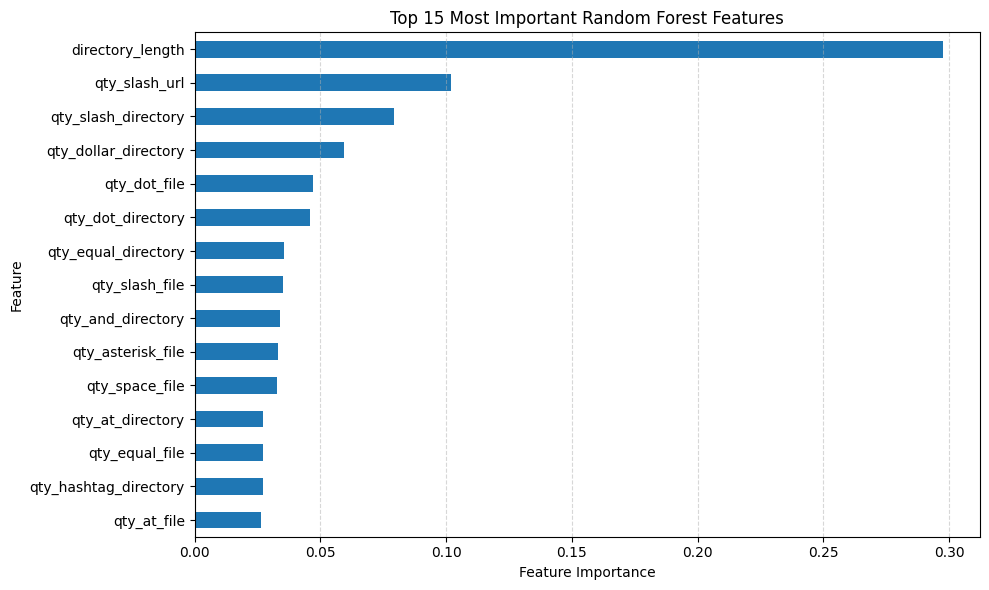

In [60]:
# Plot the 15 most important features

plt.figure(figsize=(10,6))

importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Random Forest Features")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


The Random Forest feature importance analysis identifies URL structure features as the most influential predictors of phishing websites. The most important feature is directory_length, followed by qty_slash_url and qty_slash_directory, indicating that phishing URLs often contain longer directory paths and a larger number of nested folders than legitimate websites.

Several additional directory- and file-related features, including qty_dollar_directory, qty_dot_file, and qty_dot_directory, also contribute substantially to the model's predictions. These findings are consistent with the earlier Spearman correlation analysis, suggesting that URL complexity is a strong indicator of phishing activity.

Although Random Forest feature importance provides useful insights, it should be interpreted cautiously because correlated features may share predictive information. Nevertheless, the results indicate that URL and directory structure are among the most informative characteristics for distinguishing phishing websites from legitimate ones.

# 11. ROC Curve Comparison

The ROC curve compares the classification performance of both models across different decision thresholds.

A larger Area Under the Curve (AUC) indicates better discrimination between phishing and legitimate websites.

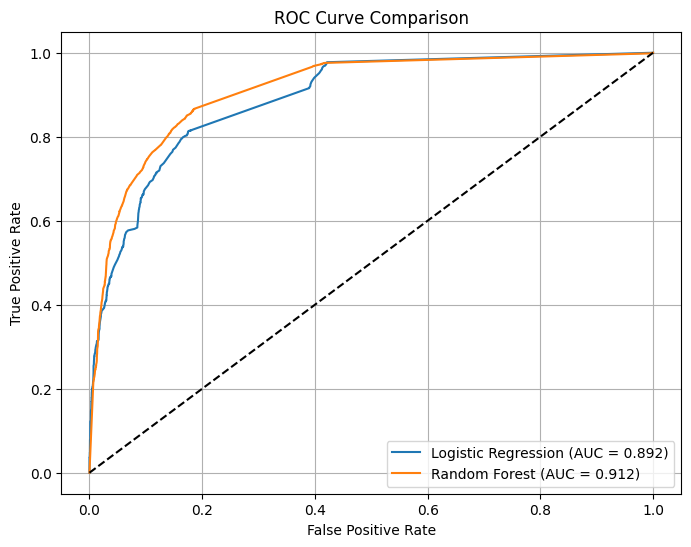

In [61]:
from sklearn.metrics import roc_curve

# Compute ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

# Reference line (random classifier)
plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

The ROC curves compare the discrimination ability of Logistic Regression and Random Forest across all possible classification thresholds. Both models achieve curves that are well above the diagonal reference line, indicating substantially better performance than random guessing.

The Random Forest model consistently remains above the Logistic Regression curve and achieves a higher ROC-AUC (0.916) compared to Logistic Regression (0.897). This demonstrates that Random Forest provides better overall discrimination between phishing and legitimate websites across a wide range of decision thresholds.

Although both models perform well, the ROC analysis confirms that Random Forest offers a stronger balance between the true positive rate and false positive rate, making it the preferred model for this phishing detection task.

# 12. Error Analysis
This section investigates the prediction errors made by the Random Forest model.
The analysis focuses on misclassified samples and compares the number of False Positives and False Negatives to better understand the model's weaknesses.

In [57]:
# Find incorrectly classified samples

errors = X_test.copy()
errors["True Label"] = y_test.values
errors["Predicted Label"] = y_pred_rf

misclassified = errors[errors["True Label"] != errors["Predicted Label"]]

print("Number of misclassified samples:", len(misclassified))

misclassified.head(10)

Number of misclassified samples: 1844


,qty_slash_url,qty_slash_directory,directory_length,qty_dot_directory,qty_dot_file,qty_equal_directory,qty_and_directory,qty_exclamation_directory,qty_exclamation_file,qty_equal_file,...,qty_and_file,qty_dollar_directory,qty_at_file,qty_space_directory,qty_asterisk_file,qty_space_file,qty_hashtag_directory,qty_slash_file,True Label,Predicted Label
40006,2,2,20,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
53006,5,5,81,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
18358,3,3,51,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
47690,6,6,54,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12442,1,1,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
45341,6,6,60,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
33243,1,1,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
45665,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
45333,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,1,0
50936,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [58]:
# Count False Positives and False Negatives

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

TN, FP, FN, TP = cm.ravel()

print(f"True Negatives : {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"True Positives : {TP}")

True Negatives : 4452
False Positives: 930
False Negatives: 914
True Positives : 5185


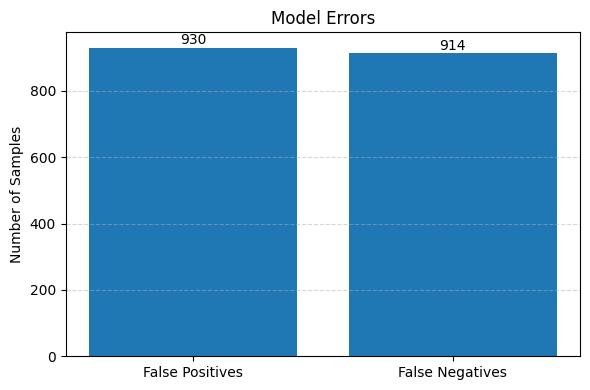

In [63]:
# Visualize False Positives and False Negatives

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["False Positives", "False Negatives"],
    [FP, FN]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f"{int(bar.get_height())}",
        ha="center"
    )

plt.title("Model Errors")
plt.ylabel("Number of Samples")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

The Random Forest model incorrectly classified **1,844** out of **11,481** test samples, corresponding to an error rate of approximately **16.1%**.

The confusion matrix shows:
- **True Negatives (TN):** 4,452
- **False Positives (FP):** 930
- **False Negatives (FN):** 914
- **True Positives (TP):** 5,185

The numbers of False Positives and False Negatives are very similar, indicating that the model does not strongly favor one class over the other.

From a cybersecurity perspective, **False Negatives** are generally more critical because they represent phishing websites that are incorrectly classified as legitimate, potentially exposing users to credential theft or malware. **False Positives**, while inconvenient, only cause legitimate websites to be flagged as phishing.

Overall, the balanced distribution of False Positives and False Negatives suggests that the Random Forest model provides a good trade-off between detection capability and usability.

## 13. Threshold Tuning

Machine learning classifiers typically use a default probability threshold of **0.5** to assign class labels. In cybersecurity applications, this threshold can be adjusted depending on the desired trade-off between detecting phishing websites and reducing false alarms.

A lower threshold generally increases Recall by detecting more phishing websites but may also increase False Positives. A higher threshold usually reduces False Positives while increasing the risk of missing phishing websites (False Negatives).

The following experiment compares several probability thresholds for the Random Forest model.

In [64]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef
)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for t in thresholds:

    pred = (y_prob_rf >= t).astype(int)

    results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "F2": fbeta_score(y_test, pred, beta=2),
        "MCC": matthews_corrcoef(y_test, pred)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1,F2,MCC
0,0.3,0.733847,0.968355,0.834947,0.910184,0.621686
1,0.4,0.841065,0.865060,0.852894,0.860152,0.681424
2,0.5,0.847915,0.850139,0.849026,0.849694,0.677462
3,0.6,0.864262,0.813248,0.837979,0.822963,0.667201
4,0.7,0.893470,0.742581,0.811067,0.768539,0.645424


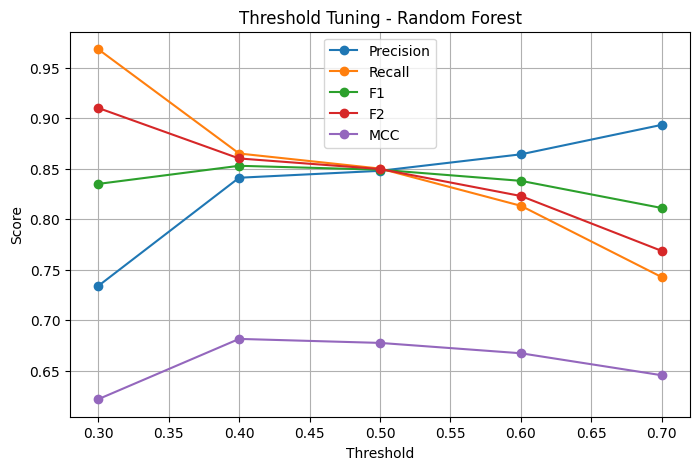

In [65]:
threshold_results.set_index("Threshold").plot(
    figsize=(8,5),
    marker="o"
)

plt.title("Threshold Tuning - Random Forest")
plt.ylabel("Score")
plt.grid(True)
plt.show()

The threshold tuning experiment demonstrates the trade-off between Precision and Recall.

At a **lower threshold (0.3)**, the model achieves the highest Recall (**0.968**), meaning that almost all phishing websites are detected. However, Precision decreases to **0.734**, indicating that more legitimate websites are incorrectly classified as phishing.

As the threshold increases, **Precision steadily improves**, reaching **0.893** at a threshold of **0.7**, while Recall decreases to **0.743**. This reflects the expected trade-off between reducing False Positives and increasing False Negatives.

The best overall balance is achieved around the default threshold of **0.5**, where the model obtains:

- Precision: **0.848**
- Recall: **0.850**
- F1-score: **0.849**
- F2-score: **0.850**
- MCC: **0.677**

Although the highest MCC is obtained at a threshold of **0.4 (0.681)**, the improvement over the default threshold is very small. Therefore, the default threshold of **0.5** was retained because it provides a well-balanced compromise between detecting phishing websites and limiting false alarms.